## Analysis Summary

### Data Overview
- **Participants**: 4 (Participant 1-4 with varying conditions: AM slow/fast, MTK slow/fast)
- **Data Points per Participant**: 7,200 rows (trimmed to standardized length)
- **Collection Date**: February 27, 2026
- **Source**: Excel log files from video tracking analysis

### Data Quality & Processing
1. **Data Loading**: Loaded 4 XLSX files containing eye tracking and gaze data
2. **Cleaning**: 
   - Replaced missing indicators (UNKNOWN, FIT_FAILED, FIND_FAILED, untracked) with NaN
   - Dropped columns with <15% valid data
   - Removed constant columns (except Gaze type and Age)
   - Converted numeric columns to appropriate data types
3. **Standardization**: All final dataframes normalized to exactly 7,200 rows

### Key Analyses Performed

#### 1. Correlation Analysis
- Computed correlations across all numeric variables
- Identified relationships between eye tracking metrics, and emotion states

#### 2. Emotion & Arousal Analysis
- Tracked 5 emotion types: Anger, Fear, Disgust, Sadness, Happiness
- Calculated mean emotion values per participant and condition
- Identified peak emotion moments during stimulus presentation
- **Key Finding**: Arousal differences between speed conditions (Fast vs. Slow)

#### 3. Gaze Pattern Analysis
- Analyzed gaze type distribution (Fixation, Saccade, Smooth Pursuit, etc.)
- Counted fixation events to measure engagement and visual attention

#### 4. Head Movement Analysis
- Computed head movement variance (Pitch, Yaw, Roll standard deviations)
- Assessed participant restlessness across conditions
- Found significant differences in head movement patterns

### Variables & Outputs
- **final_dataframes**: Dictionary containing 4 cleaned participant datasets (7,200 rows each)
- **Visualizations**: 
  - Correlation heatmaps
  - Time-series plots of emotions and head movement
  - Head movement variance by participant type and speed
  - Gaze type distribution plots

In [3]:
import pandas as pd
import os
from pathlib import Path

# Set up paths
logs_dir = Path('./Logs')
log_files = sorted(logs_dir.glob('*.xlsx'))

print(f"Found {len(log_files)} log files:")
for file in log_files:
    print(f"  - {file.name}")

Found 4 log files:
  - Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed.xlsx
  - Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed.xlsx
  - Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed.xlsx
  - Participant 4_MTK slow_Analysis 1_video_20260227_104443_detailed.xlsx


In [11]:
## Data Preview
# Load all dataframes into a dictionary
dataframes = {}

for file in log_files:
    raw = pd.read_excel(file, header=None)

    # Find row where first column equals "Video Time"
    header_row = raw[raw.iloc[:,0] == "Video Time"].index[0]

    df = pd.read_excel(file, skiprows=header_row)
    df = df.dropna(axis=1, how="all")

    key = file.stem
    dataframes[key] = df

    print(f"\n{key}")
    print(f"Shape: {df.shape}")
    print(df.head(2))


Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed
Shape: (7528, 55)
     Video Time   Neutral     Happy Sad     Angry Surprised    Scared  \
0  00:00:00.000  0.981247  0.000121   0  0.002981  0.000106  0.024811   
1  00:00:00.008  0.981137  0.000118   0  0.002909  0.000104  0.025248   

  Disgusted  Contempt   Valence  ... Sad from Voice Angry from Voice  \
0         0  0.001463 -0.024689  ...        UNKNOWN          UNKNOWN   
1         0  0.001451 -0.025129  ...        UNKNOWN          UNKNOWN   

  Valence from Voice Arousal from Voice Loudness Speech rate  \
0            UNKNOWN            UNKNOWN  UNKNOWN     UNKNOWN   
1            UNKNOWN            UNKNOWN  UNKNOWN     UNKNOWN   

                      Gaze type Gaze Location X Gaze Location Y Fixation Index  
0  Unknown (Fixation / Saccade)         UNKNOWN         UNKNOWN        UNKNOWN  
1                       Saccade         UNKNOWN         UNKNOWN        UNKNOWN  

[2 rows x 55 columns]

Participant 2_AM fas

In [12]:
# Create individual dataframe variables for easy access
for key, df in dataframes.items():
    var_name = key.replace(' ', '_').replace('-', '_')
    globals()[var_name] = df

# Display available dataframes
print("\nAvailable dataframes:")
for var in sorted(globals().keys()):
    if isinstance(globals()[var], pd.DataFrame):
        print(f"  - {var}")


Available dataframes:
  - Participant_1_AM_slow_Analysis_1_video_20260227_104338_detailed
  - Participant_2_AM_fast_Analysis_1_video_20260227_104405_detailed
  - Participant_3_MTK_fast_Analysis_1_video_20260227_104420_detailed
  - Participant_4_MTK_slow_Analysis_1_video_20260227_104443_detailed
  - df
  - first_df
  - raw


In [9]:
# Preview first dataframe
first_df = list(dataframes.values())[0]
print("Sample of first dataframe:")
print(first_df.head())
print(f"\nData types:\n{first_df.dtypes}")

Sample of first dataframe:
     Video Time   Neutral     Happy Sad     Angry Surprised    Scared  \
0  00:00:00.000  0.981247  0.000121   0  0.002981  0.000106  0.024811   
1  00:00:00.008  0.981137  0.000118   0  0.002909  0.000104  0.025248   
2  00:00:00.016  0.981066  0.000116   0   0.00284  0.000102  0.025505   
3  00:00:00.025  0.981283  0.000113   0  0.002772  0.000099  0.025279   
4  00:00:00.033  0.981421   0.00011   0  0.002724  0.000098  0.025062   

  Disgusted  Contempt   Valence  ... Sad from Voice Angry from Voice  \
0         0  0.001463 -0.024689  ...        UNKNOWN          UNKNOWN   
1         0  0.001451 -0.025129  ...        UNKNOWN          UNKNOWN   
2         0  0.001431 -0.025389  ...        UNKNOWN          UNKNOWN   
3         0  0.001414 -0.025166  ...        UNKNOWN          UNKNOWN   
4         0  0.001387 -0.024952  ...        UNKNOWN          UNKNOWN   

  Valence from Voice Arousal from Voice Loudness Speech rate  \
0            UNKNOWN            UNKNO

In [13]:
import pandas as pd
import numpy as np

# Assuming 'dataframes' dictionary is already populated using your code

cleaned_dataframes = {}

# List of strings that represent missing data in your export
missing_values = ["UNKNOWN", "FIT_FAILED", "FIND_FAILED", "untracked"]

for key, df in dataframes.items():
    # Make a copy to avoid SettingWithCopy warnings
    df_clean = df.copy()
    
    # Replace known missing value strings with NaN
    df_clean.replace(missing_values, np.nan, inplace=True)
    
    # Columns to keep as strings/objects (metadata)
    meta_cols = ['Video Time', 'Gender', 'Age', 'Glasses', 'Gaze type', 'Participant Name', 'Stimulus', 'Event Marker']
    
    # Convert all other columns to numeric
    for col in df_clean.columns:
        if col not in meta_cols:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            
    # Optional: Convert 'Video Time' to a timedelta or datetime object for time-series plotting
    df_clean['Video Time'] = pd.to_timedelta(df_clean['Video Time'], errors='coerce')
    
    cleaned_dataframes[key] = df_clean
    
    print(f"{key} successfully cleaned!")

Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed successfully cleaned!
Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed successfully cleaned!
Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed successfully cleaned!
Participant 4_MTK slow_Analysis 1_video_20260227_104443_detailed successfully cleaned!


In [15]:
# Preview first dataframe
first_df = list(cleaned_dataframes.values())[0]
print("Sample of first dataframe:")
print(first_df.head())
print(f"\nData types:\n{first_df.dtypes}")

Sample of first dataframe:
              Video Time   Neutral     Happy  Sad     Angry  Surprised  \
0        0 days 00:00:00  0.981247  0.000121  0.0  0.002981   0.000106   
1 0 days 00:00:00.008000  0.981137  0.000118  0.0  0.002909   0.000104   
2 0 days 00:00:00.016000  0.981066  0.000116  0.0  0.002840   0.000102   
3 0 days 00:00:00.025000  0.981283  0.000113  0.0  0.002772   0.000099   
4 0 days 00:00:00.033000  0.981421  0.000110  0.0  0.002724   0.000098   

     Scared  Disgusted  Contempt   Valence  ...  Sad from Voice  \
0  0.024811        0.0  0.001463 -0.024689  ...             NaN   
1  0.025248        0.0  0.001451 -0.025129  ...             NaN   
2  0.025505        0.0  0.001431 -0.025389  ...             NaN   
3  0.025279        0.0  0.001414 -0.025166  ...             NaN   
4  0.025062        0.0  0.001387 -0.024952  ...             NaN   

  Angry from Voice Valence from Voice Arousal from Voice  Loudness  \
0              NaN                NaN                Na

In [54]:
import pandas as pd
import numpy as np

def inspect_dataframe_columns(df):
    """
    Inspects each column to find the percentage of missing/null values
    and prints either numeric metrics or unique string values.
    """
    
    missing_indicators = ["UNKNOWN", "FIT_FAILED", "FIND_FAILED", "untracked", "Unknown (Fixation / Saccade)"]
    
    # Work on a copy so we don't accidentally mutate the original data
    temp_df = df.replace(missing_indicators, np.nan)
    total_rows = len(temp_df)
    
    summary_data = []
    
    for col in temp_df.columns:
        # 1. Calculate the percentage of missing values
        null_count = temp_df[col].isna().sum()
        null_pct = (null_count / total_rows) * 100
        
        # 2. Try to convert to numeric using 'coerce'
        numeric_series = pd.to_numeric(temp_df[col], errors='coerce')
        
        # 3. Determine if the column is actually numeric
        # If coercing to numeric didn't create any NEW nulls, it's a numeric column
        is_numeric = (numeric_series.notna().sum() == temp_df[col].notna().sum()) and (temp_df[col].notna().sum() > 0)
        
        if is_numeric:
            metrics = f"Min: {numeric_series.min():.3f} | Max: {numeric_series.max():.3f} | Mean: {numeric_series.mean():.3f}"
        else:
            # It's a categorical / string column
            if null_count == total_rows:
                metrics = "All Null"
            else:
                unique_vals = temp_df[col].dropna().unique()
                if len(unique_vals) <= 5:
                    metrics = f"Unique ({len(unique_vals)}): {list(unique_vals)}"
                else:
                    metrics = f"Unique ({len(unique_vals)}): {list(unique_vals[:5])}..."
                    
        summary_data.append({
            "Column": col,
            "Null %": f"{null_pct:.1f}%",
            "Metrics": metrics
        })
        
    # Return as a formatted DataFrame for easy viewing
    return pd.DataFrame(summary_data)


# Run the inspection on the first dataframe in your dictionary
first_key = list(cleaned_dataframes.keys())[0]
print(f"--- Column Inspection for: {first_key} ---")

summary_df = inspect_dataframe_columns(cleaned_dataframes[first_key])

# Increase pandas display limits so you can see all 55 rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print(summary_df)

--- Column Inspection for: Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed ---
                            Column  Null %  \
0                       Video Time    0.0%   
1                          Neutral    1.2%   
2                            Happy    1.2%   
3                              Sad    1.2%   
4                            Angry    1.2%   
5                        Surprised    1.2%   
6                           Scared    1.2%   
7                        Disgusted    1.2%   
8                         Contempt    1.2%   
9                          Valence    1.2%   
10                         Arousal    1.2%   
11                          Gender    1.2%   
12                             Age    1.2%   
13                         Glasses    1.2%   
14                           Pitch    1.2%   
15                             Yaw    1.2%   
16                            Roll    1.2%   
17                       Landmarks  100.0%   
18                    3d Landma

In [107]:
import pandas as pd
import numpy as np

def inspect_dataframe_columns(df):
    """
    Inspects each column to find the percentage of missing/null values
    and prints either numeric metrics or unique string values.
    """
    
    missing_indicators = ["UNKNOWN", "FIT_FAILED", "FIND_FAILED", "untracked", "Unknown (Fixation / Saccade)"]
    
    # Work on a copy so we don't accidentally mutate the original data
    temp_df = df.replace(missing_indicators, np.nan)
    total_rows = len(temp_df)
    
    summary_data = []
    
    for col in temp_df.columns:
        # 1. Calculate the percentage of missing values
        null_count = temp_df[col].isna().sum()
        null_pct = (null_count / total_rows) * 100
        
        # 2. Try to convert to numeric using 'coerce'
        numeric_series = pd.to_numeric(temp_df[col], errors='coerce')
        
        # 3. Determine if the column is actually numeric
        # If coercing to numeric didn't create any NEW nulls, it's a numeric column
        is_numeric = (numeric_series.notna().sum() == temp_df[col].notna().sum()) and (temp_df[col].notna().sum() > 0)
        
        if is_numeric:
            metrics = f"Min: {numeric_series.min():.3f} | Max: {numeric_series.max():.3f} | Mean: {numeric_series.mean():.3f}"
        else:
            # It's a categorical / string column
            if null_count == total_rows:
                metrics = "All Null"
            else:
                unique_vals = temp_df[col].dropna().unique()
                if len(unique_vals) <= 5:
                    metrics = f"Unique ({len(unique_vals)}): {list(unique_vals)}"
                else:
                    metrics = f"Unique ({len(unique_vals)}): {list(unique_vals[:5])}..."
                    
        summary_data.append({
            "Column": col,
            "Null %": f"{null_pct:.1f}%",
            "Metrics": metrics
        })
        
    # Return as a formatted DataFrame for easy viewing
    return pd.DataFrame(summary_data)


# Run the inspection on the first dataframe in your dictionary
first_key = list(cleaned_dataframes.keys())[3]
print(f"--- Column Inspection for: {first_key} ---")

summary_df = inspect_dataframe_columns(cleaned_dataframes[first_key])

# Increase pandas display limits so you can see all 55 rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

print(summary_df)

--- Column Inspection for: Participant 4_MTK slow_Analysis 1_video_20260227_104443_detailed ---
                            Column  Null %  \
0                       Video Time    0.0%   
1                          Neutral    0.0%   
2                            Happy    0.0%   
3                              Sad    0.0%   
4                            Angry    0.0%   
5                        Surprised    0.0%   
6                           Scared    0.0%   
7                        Disgusted    0.0%   
8                         Contempt    0.0%   
9                          Valence    0.0%   
10                         Arousal    0.0%   
11                          Gender    0.0%   
12                             Age    0.0%   
13                         Glasses    0.0%   
14                           Pitch    0.0%   
15                             Yaw    0.0%   
16                            Roll    0.0%   
17                       Landmarks  100.0%   
18                    3d Landm

In [58]:
# Create a new dictionary for the heavily cleaned data
final_dataframes = {}

for key, df in cleaned_dataframes.items():
    # 1. Replace the missing indicators with true NaNs first
    missing_indicators = ["UNKNOWN", "FIT_FAILED", "FIND_FAILED", "untracked", "Unknown (Fixation / Saccade)"]
    df_clean = df.replace(missing_indicators, np.nan)
    
    # 2. Calculate the threshold: Keep columns that have AT LEAST 15% valid data
    # (This drops columns that are 85% to 100% null)
    valid_threshold = int(0.15 * len(df_clean))
    df_clean = df_clean.dropna(axis=1, thresh=valid_threshold)
    
    cols_to_drop = []
    for col in df_clean.columns:
        # Check if there is only 1 unique value after dropping NaNs
        if df_clean[col].dropna().nunique() == 1 and col!= 'Gaze type' and col!= 'Age':
            cols_to_drop.append(col)
            
    df_clean = df_clean.drop(columns=cols_to_drop)
    # 3. Save to our final dictionary
    final_dataframes[key] = df_clean
    
    print(f"{key}: Reduced from {df.shape} to {df_clean.shape}.")

Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed: Reduced from (7528, 55) to (7528, 26).
Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed: Reduced from (7267, 53) to (7267, 26).
Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed: Reduced from (7337, 54) to (7337, 26).
Participant 4_MTK slow_Analysis 1_video_20260227_104443_detailed: Reduced from (7358, 54) to (7358, 26).


In [59]:
# Extract the column names as sets for easy comparison
df_columns = {name: set(df.columns) for name, df in final_dataframes.items()}

# 1. Print the columns for each dataframe
for name, cols in df_columns.items():
    print(f"\n--- {name} ---")
    # Sorting them makes it easier to read visually
    print(f"Columns ({len(cols)}): {sorted(list(cols))}")

print("\n" + "="*50)

# 2. Automatically check if they all match the first dataframe
col_sets_list = list(df_columns.values())
all_identical = all(cols == col_sets_list[0] for cols in col_sets_list)

if all_identical:
    print("RESULT: Success! All dataframes have the EXACT SAME columns.")
else:
    print("RESULT: There are DIFFERENCES in the columns across the dataframes.")
    
    # Find the common columns and the unique ones
    common_cols = set.intersection(*df_columns.values())
    for name, cols in df_columns.items():
        unique_to_this_df = cols - common_cols
        if unique_to_this_df:
            print(f"{name} has unique columns: {unique_to_this_df}")


--- Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed ---
Columns (26): ['Age', 'Angry', 'Arousal', 'Breathing Rate', 'Breathing rate confidence', 'Contempt', 'Depth position', 'Disgusted', 'Gaze type', 'Happy', 'Heart Rate', 'Heart rate confidence', 'Horizontal gaze angle', 'Horizontal position', 'Neutral', 'Pitch', 'Quality', 'Roll', 'Sad', 'Scared', 'Surprised', 'Valence', 'Vertical gaze angle', 'Vertical position', 'Video Time', 'Yaw']

--- Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed ---
Columns (26): ['Age', 'Angry', 'Arousal', 'Breathing Rate', 'Breathing rate confidence', 'Contempt', 'Depth position', 'Disgusted', 'Gaze type', 'Happy', 'Heart Rate', 'Heart rate confidence', 'Horizontal gaze angle', 'Horizontal position', 'Neutral', 'Pitch', 'Quality', 'Roll', 'Sad', 'Scared', 'Surprised', 'Valence', 'Vertical gaze angle', 'Vertical position', 'Video Time', 'Yaw']

--- Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed ---
Columns 

In [61]:
# Check row counts for all final dataframes
print("Row counts for final_dataframes:")
for key, df in final_dataframes.items():
    print(f"{key}: {len(df)} rows")

# Ensure all final dataframes have exactly 7200 rows
print("\nTrimming all dataframes to 7200 rows...")
for key in final_dataframes:
    original_count = len(final_dataframes[key])
    final_dataframes[key] = final_dataframes[key].iloc[:7200]
    new_count = len(final_dataframes[key])
    print(f"{key}: {original_count} → {new_count} rows")

print("\nFinal row counts after trimming:")
for key, df in final_dataframes.items():
    print(f"{key}: {len(df)} rows")


Row counts for final_dataframes:
Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed: 7528 rows
Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed: 7267 rows
Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed: 7337 rows
Participant 4_MTK slow_Analysis 1_video_20260227_104443_detailed: 7358 rows

Trimming all dataframes to 7200 rows...
Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed: 7528 → 7200 rows
Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed: 7267 → 7200 rows
Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed: 7337 → 7200 rows
Participant 4_MTK slow_Analysis 1_video_20260227_104443_detailed: 7358 → 7200 rows

Final row counts after trimming:
Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed: 7200 rows
Participant 2_AM fast_Analysis 1_video_20260227_104405_detailed: 7200 rows
Participant 3_MTK fast_Analysis 1_video_20260227_104420_detailed: 7200 rows
Participant 4_MTK slow_Analysis 1_

In [76]:
import pandas as pd

master_list = []

for key, df in final_dataframes.items():
    # Work on a copy
    temp_df = df.copy()
    
    # 1. Extract condition data from the filename (the 'key')
    # Example key: "Participant 1_AM slow_Analysis 1_video_20260227_104338_detailed"
    parts = key.split('_')
    
    # Participant ID (e.g., "Participant 1")
    temp_df['Participant'] = parts[0]
    
    # Condition string (e.g., "AM slow")
    condition_str = parts[1] 
    
    # Split into Type (AM/MTK) and Speed (slow/fast)
    temp_df['Type'] = condition_str.split(' ')[0]
    temp_df['Speed'] = condition_str.split(' ')[1]
    
    # 2. Convert 'Video Time' from a string format (HH:MM:SS.ms) to total seconds
    # This makes time-series plotting much easier
    temp_df['Time_Seconds'] = pd.to_timedelta(temp_df['Video Time']).dt.total_seconds()
    
    # 3. Append to our list
    master_list.append(temp_df)

# 4. Concatenate all dataframes into one
master_df = pd.concat(master_list, ignore_index=True)

print(f"Master DataFrame created! Shape: {master_df.shape}")
print(master_df[['Participant', 'Type', 'Speed', 'Time_Seconds']].head())

Master DataFrame created! Shape: (28800, 30)
     Participant Type Speed  Time_Seconds
0  Participant 1   AM  slow         0.000
1  Participant 1   AM  slow         0.008
2  Participant 1   AM  slow         0.016
3  Participant 1   AM  slow         0.025
4  Participant 1   AM  slow         0.033


In [77]:
cols_to_interpolate = ['Heart Rate', 'Breathing Rate']

for col in cols_to_interpolate:
    master_df[col] = master_df.groupby('Participant')[col].transform(
        lambda group: group.interpolate(method='linear', limit_direction='both')
    )

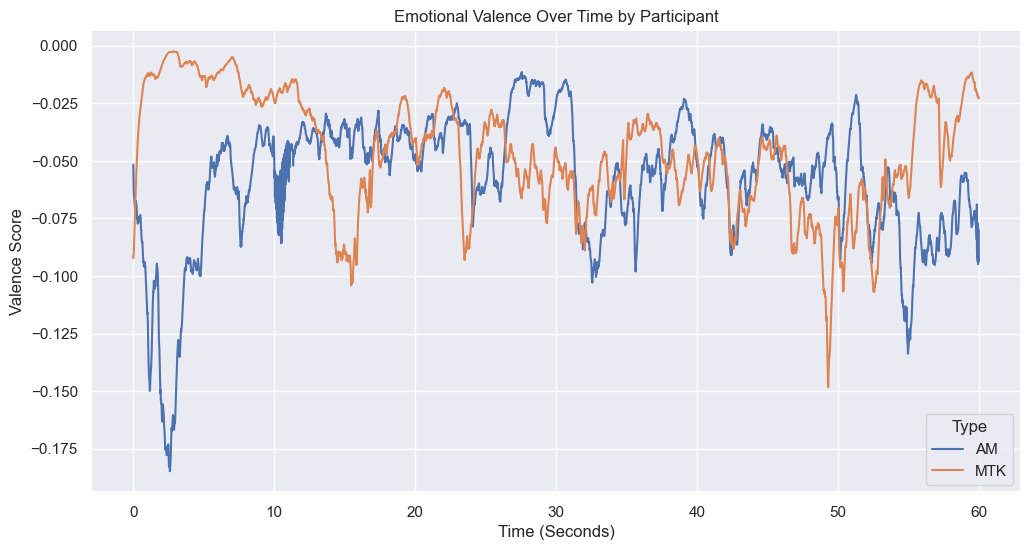

In [81]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

# Plot Valence (Positivity/Negativity) over time, separated by Type (AM vs MTK)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=master_df, 
    x='Time_Seconds', 
    y='Valence', 
    hue='Type', 
    errorbar=None  # Turn off confidence intervals for a cleaner line if desired
)
plt.title('Emotional Valence Over Time by Participant')
plt.xlabel('Time (Seconds)')
plt.ylabel('Valence Score')
plt.show()

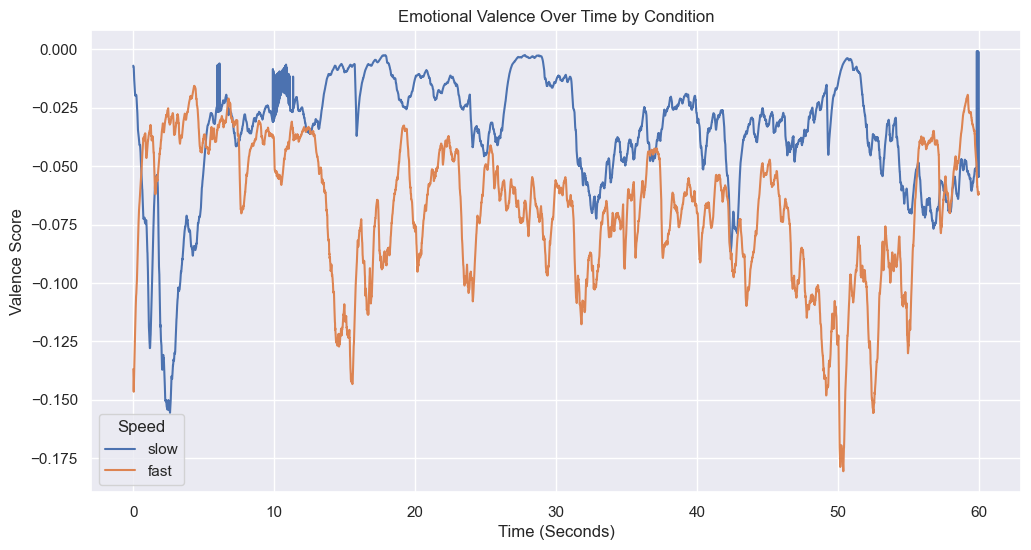

In [82]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")

# Plot Valence (Positivity/Negativity) over time, separated by Type (AM vs MTK)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=master_df, 
    x='Time_Seconds', 
    y='Valence', 
    hue='Speed', 
    errorbar=None  # Turn off confidence intervals for a cleaner line if desired
)
plt.title('Emotional Valence Over Time by Condition')
plt.xlabel('Time (Seconds)')
plt.ylabel('Valence Score')
plt.show()

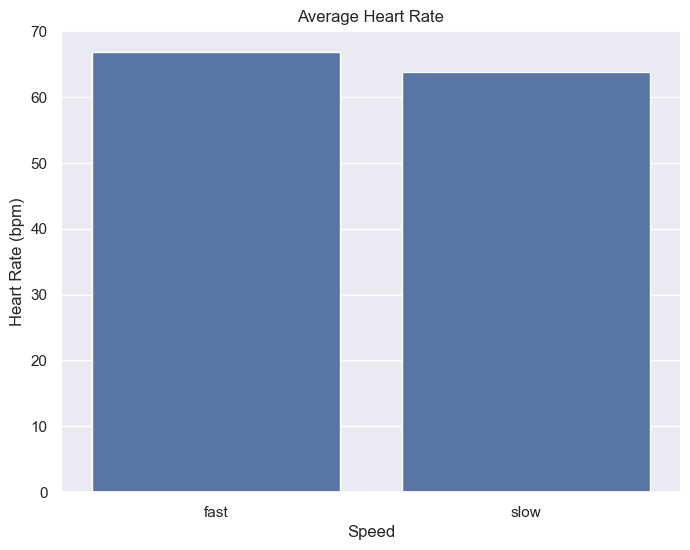

In [83]:
# Group the data to see the mean scores for key metrics
summary_stats = master_df.groupby(['Speed'])[['Valence', 'Arousal', 'Heart Rate']].mean().reset_index()

# Display a bar plot comparing Heart Rate across conditions
plt.figure(figsize=(8, 6))
sns.barplot(data=summary_stats, x='Speed', y='Heart Rate')
plt.title('Average Heart Rate')
plt.ylabel('Heart Rate (bpm)')
plt.show()

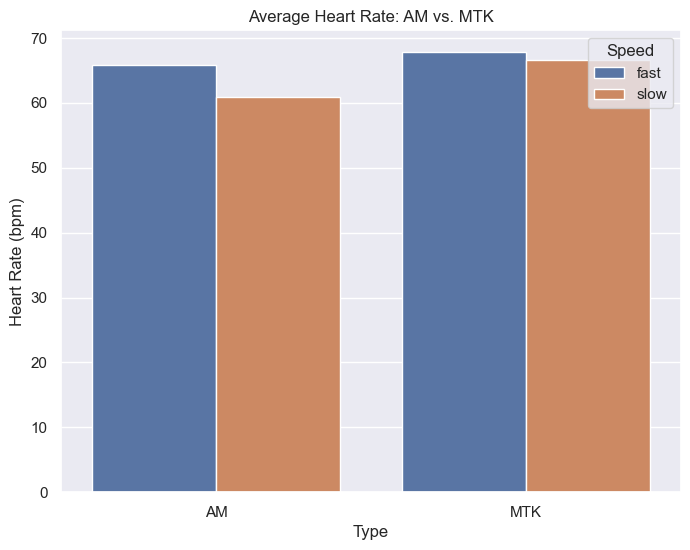

In [105]:
# Group the data to see the mean scores for key metrics
summary_stats = master_df.groupby(['Type', 'Speed'])[['Valence', 'Heart Rate']].mean().reset_index()

# Display a bar plot comparing Heart Rate across conditions
plt.figure(figsize=(8, 6))
sns.barplot(data=summary_stats, x='Type', y='Heart Rate', hue='Speed')
plt.title('Average Heart Rate: AM vs. MTK')
plt.ylabel('Heart Rate (bpm)')
plt.show()

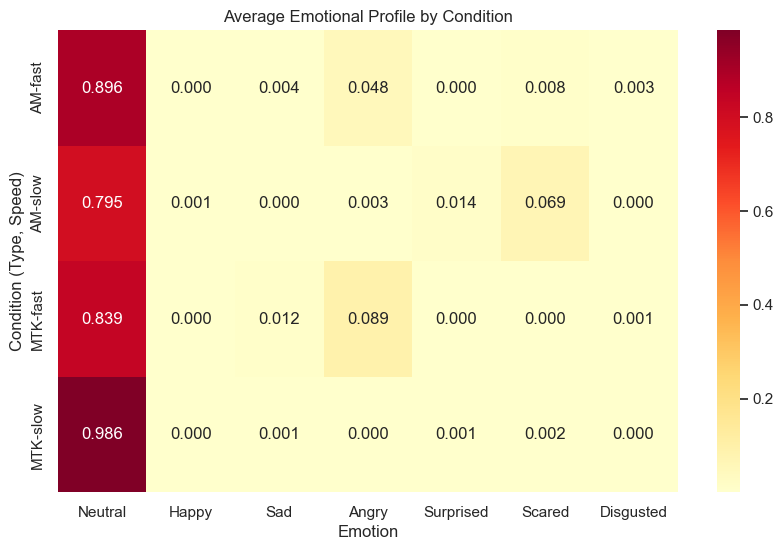

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The 7 core emotions tracked in your dataset
emotions = ['Neutral', 'Happy', 'Sad', 'Angry', 'Surprised', 'Scared', 'Disgusted']

# Calculate the mean for each emotion, grouped by Type and Speed
emotion_means = master_df.groupby(['Type', 'Speed'])[emotions].mean()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(emotion_means, annot=True, cmap="YlOrRd", fmt=".3f")
plt.title('Average Emotional Profile by Condition')
plt.ylabel('Condition (Type, Speed)')
plt.xlabel('Emotion')
plt.show()

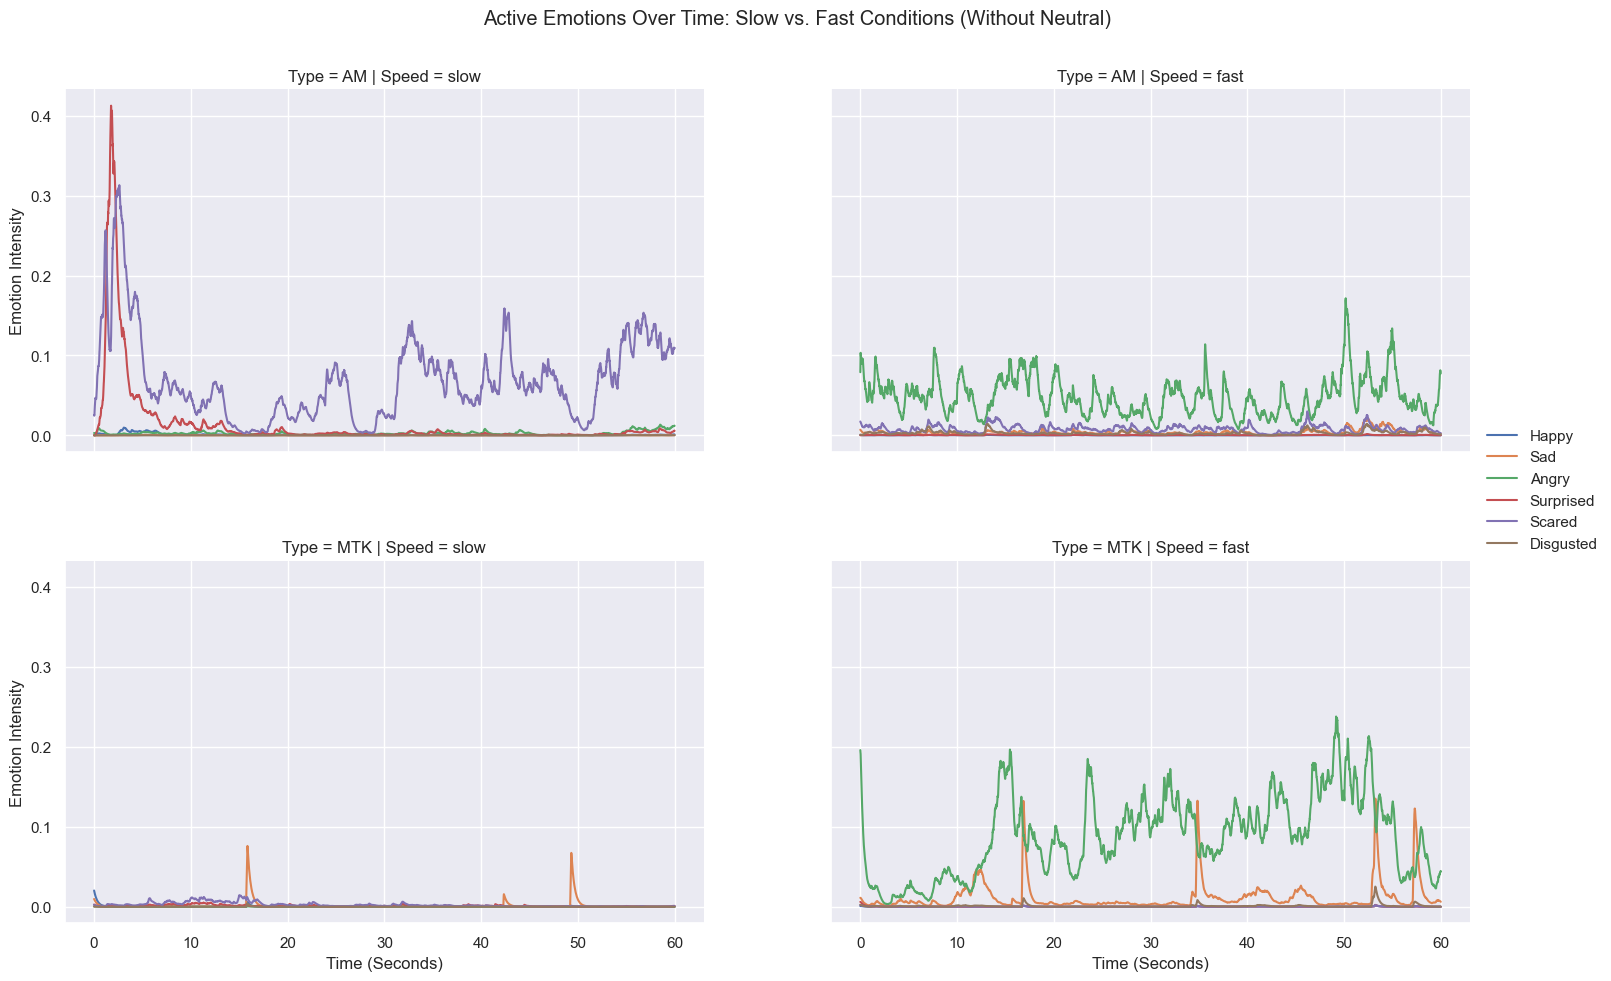

In [95]:
# Create a 'long' format dataframe which is better for Seaborn's multi-line plots
# We are melting the 6 active emotions into a single 'Emotion' column
active_emotions = ['Happy', 'Sad', 'Angry', 'Surprised', 'Scared', 'Disgusted']
melted_df = master_df.melt(
    id_vars=['Time_Seconds', 'Type', 'Speed'], 
    value_vars=active_emotions,
    var_name='Emotion', 
    value_name='Intensity'
)

# Create a grid of plots separating by Speed (columns) and Type (rows)
g = sns.FacetGrid(melted_df, col="Speed", row="Type", height=5, aspect=1.5)

# Map a lineplot to each grid cell, plotting all active emotions
g.map_dataframe(sns.lineplot, x="Time_Seconds", y="Intensity", hue="Emotion", errorbar=None)

# Add legends and titles
g.add_legend()
g.set_axis_labels("Time (Seconds)", "Emotion Intensity")
plt.subplots_adjust(top=0.9, hspace=0.3, wspace=0.2)  # Adjust spacing to prevent title overlap
g.fig.suptitle('Active Emotions Over Time: Slow vs. Fast Conditions (Without Neutral)')
plt.show()

In [97]:
# Find the maximum value reached for each emotion
emotion_peaks = master_df.groupby(['Type', 'Speed'])[emotions].max().reset_index()

print("--- Peak Emotion Intensity by Condition ---")
emotion_peaks

--- Peak Emotion Intensity by Condition ---


,Type,Speed,Neutral,Happy,Sad,Angry,Surprised,Scared,Disgusted
0,AM,fast,0.971486,0.000676,0.020923,0.171537,0.001740,0.029953,0.014391
1,AM,slow,0.984015,0.009746,0.000613,0.013360,0.412575,0.313104,0.000224
2,MTK,fast,0.984673,0.001827,0.135354,0.238082,0.006123,0.002350,0.025261
3,MTK,slow,0.998213,0.020325,0.076121,0.000639,0.005435,0.014245,0.003986


In [98]:
master_df.columns

Index(['Video Time', 'Neutral', 'Happy', 'Sad', 'Angry', 'Surprised', 'Scared',
       'Disgusted', 'Contempt', 'Valence', 'Arousal', 'Age', 'Pitch', 'Yaw',
       'Roll', 'Quality', 'Heart Rate', 'Heart rate confidence',
       'Breathing Rate', 'Breathing rate confidence', 'Horizontal position',
       'Vertical position', 'Depth position', 'Horizontal gaze angle',
       'Vertical gaze angle', 'Gaze type', 'Participant', 'Type', 'Speed',
       'Time_Seconds'],
      dtype='str')

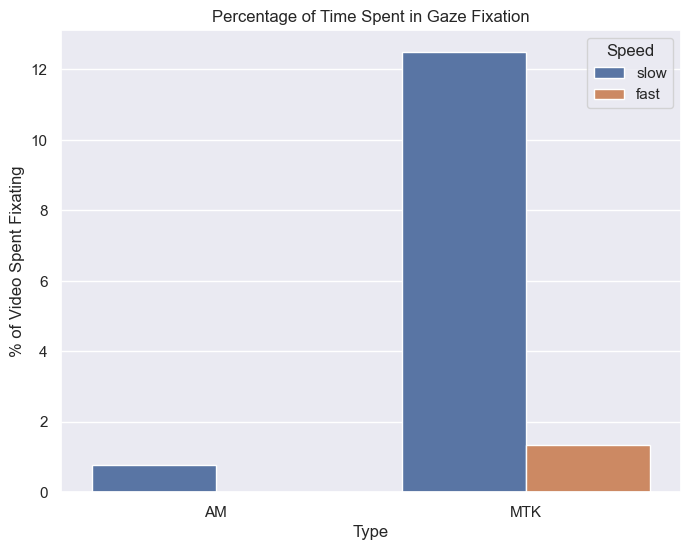

In [101]:
# Calculate the count of each gaze type per condition
gaze_counts = master_df.groupby(['Type', 'Speed', 'Gaze type']).size().reset_index(name='Count')

# Calculate the total frames per condition to get percentages
total_frames = gaze_counts.groupby(['Type', 'Speed'])['Count'].transform('sum')
gaze_counts['Percentage'] = (gaze_counts['Count'] / total_frames) * 100

# Filter to just look at the percentage of Fixations
fixations_only = gaze_counts[gaze_counts['Gaze type'] == 'Fixation']

plt.figure(figsize=(8, 6))
sns.barplot(data=fixations_only, x='Type', y='Percentage', hue='Speed')
plt.title('Percentage of Time Spent in Gaze Fixation')
plt.ylabel('% of Video Spent Fixating')
plt.show()

--- Head Movement Variance (Restlessness) ---
  Type Speed     Pitch       Yaw      Roll
0   AM  fast  3.212607  6.527815  1.849135
1   AM  slow  2.938437  5.105278  2.612903
2  MTK  fast  0.651323  1.646461  1.203681
3  MTK  slow  1.150942  1.196979  1.304972


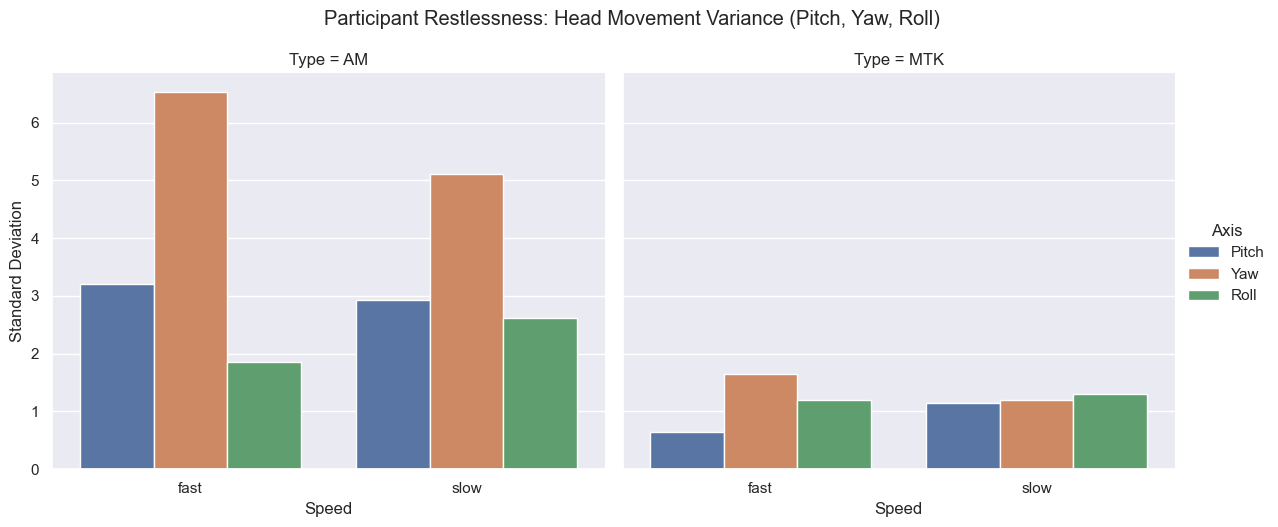

In [104]:
# Calculate the standard deviation of head movements for each condition
head_movement_std = master_df.groupby(['Type', 'Speed'])[['Pitch', 'Yaw', 'Roll']].std().reset_index()

print("--- Head Movement Variance (Restlessness) ---")
print(head_movement_std)

# 1. Melt the data for easy plotting
melted_head = head_movement_std.melt(
    id_vars=['Type', 'Speed'], 
    var_name='Axis', 
    value_name='Standard Deviation'
)

# 2. Use catplot instead of barplot to support the 'col' parameter
g = sns.catplot(
    data=melted_head, 
    kind='bar',
    x='Speed', 
    y='Standard Deviation', 
    hue='Axis', 
    col='Type',
    height=5, 
    aspect=1.2
)

# 3. Add titles and adjust layout
g.fig.suptitle('Participant Restlessness: Head Movement Variance (Pitch, Yaw, Roll)', y=1.05)
plt.show()

## Gaze angles

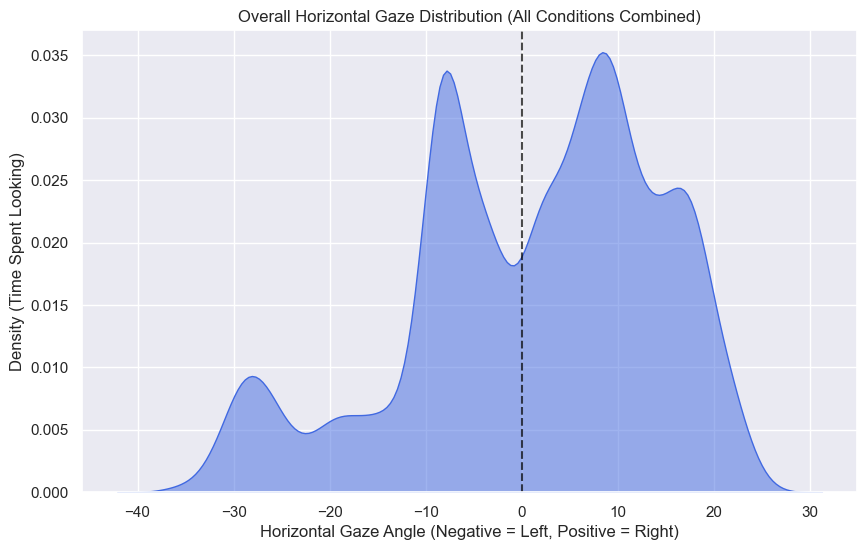

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# A single KDE plot for the entire dataset
sns.kdeplot(
    data=master_df, 
    x='Horizontal gaze angle', 
    fill=True, 
    alpha=0.5,
    color='royalblue'
)

# Add a vertical line at 0 (center of the screen)
plt.axvline(0, color='black', linestyle='--', alpha=0.7)

plt.title('Overall Horizontal Gaze Distribution (All Conditions Combined)')
plt.xlabel('Horizontal Gaze Angle (Negative = Left, Positive = Right)')
plt.ylabel('Density (Time Spent Looking)')
plt.show()

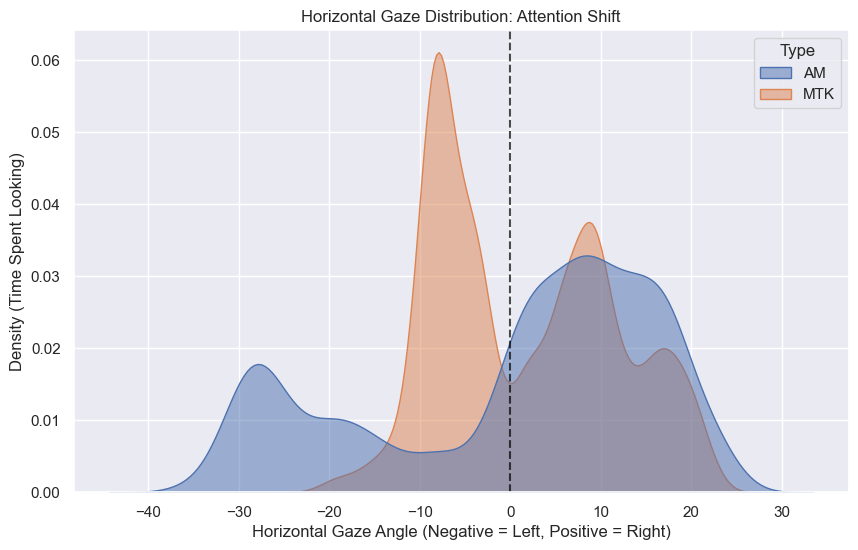

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# A KDE (Kernel Density Estimate) plot shows where the eyes spent the most time
sns.kdeplot(
    data=master_df, 
    x='Horizontal gaze angle', 
    hue='Type',      # Compare AM vs MTK
    fill=True, 
    common_norm=False, 
    alpha=0.5
)

# Add a vertical line at 0 (center of the screen)
plt.axvline(0, color='black', linestyle='--', alpha=0.7)

plt.title('Horizontal Gaze Distribution: Attention Shift')
plt.xlabel('Horizontal Gaze Angle (Negative = Left, Positive = Right)')
plt.ylabel('Density (Time Spent Looking)')
plt.show()

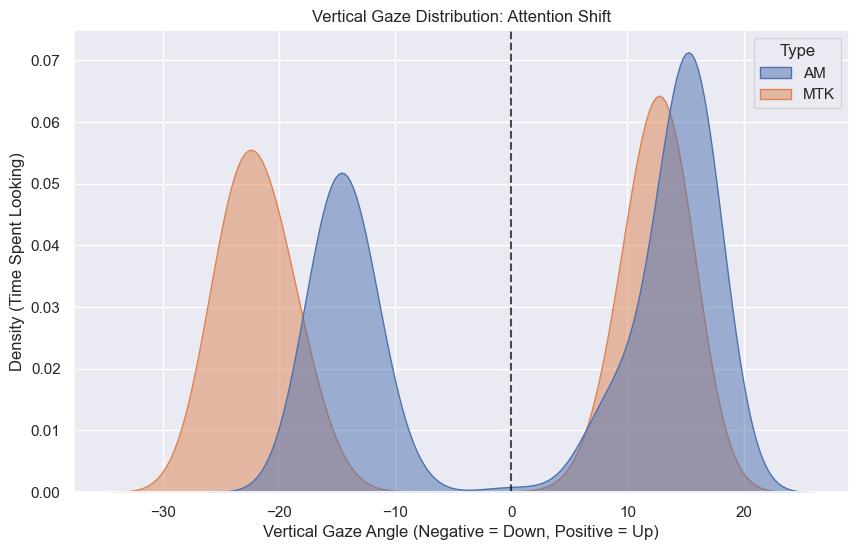

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# A KDE (Kernel Density Estimate) plot shows where the eyes spent the most time
sns.kdeplot(
    data=master_df, 
    x='Vertical gaze angle', 
    hue='Type',      # Compare AM vs MTK
    fill=True, 
    common_norm=False, 
    alpha=0.5
)

# Add a vertical line at 0 (eye-level/center of the screen vertically)
plt.axvline(0, color='black', linestyle='--', alpha=0.7)

plt.title('Vertical Gaze Distribution: Attention Shift')
plt.xlabel('Vertical Gaze Angle (Negative = Down, Positive = Up)')
plt.ylabel('Density (Time Spent Looking)')
plt.show()

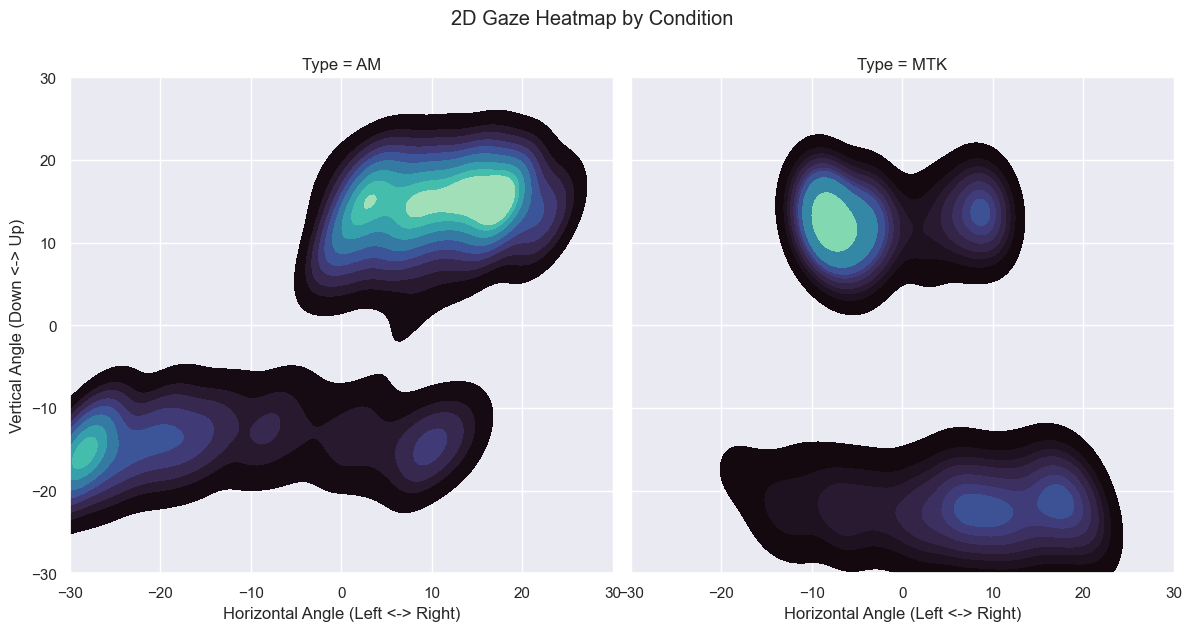

In [109]:
# Create a 2D density plot separated by the 'Type' condition
g = sns.FacetGrid(master_df, col="Type", height=6, aspect=1)

# Map a 2D KDE plot to simulate a screen heatmap
g.map_dataframe(
    sns.kdeplot, 
    x="Horizontal gaze angle", 
    y="Vertical gaze angle", 
    fill=True, 
    cmap="mako", 
    thresh=0.05, 
    levels=10
)

# Set the limits so the "screens" are identical in size for comparison
# Adjust these min/max values based on your dataset's actual range
g.set(xlim=(-30, 30), ylim=(-30, 30))

g.fig.suptitle('2D Gaze Heatmap by Condition', y=1.05)
g.set_axis_labels("Horizontal Angle (Left <-> Right)", "Vertical Angle (Down <-> Up)")
plt.show()

--- Gaze Variance (Visual Searching Behavior) ---
  Type Speed  Horizontal gaze angle  Vertical gaze angle
0   AM  fast              14.364776             2.169640
1   AM  slow               6.835513             3.193940
2  MTK  fast              10.432596             2.352923
3  MTK  slow               6.634527             2.017083


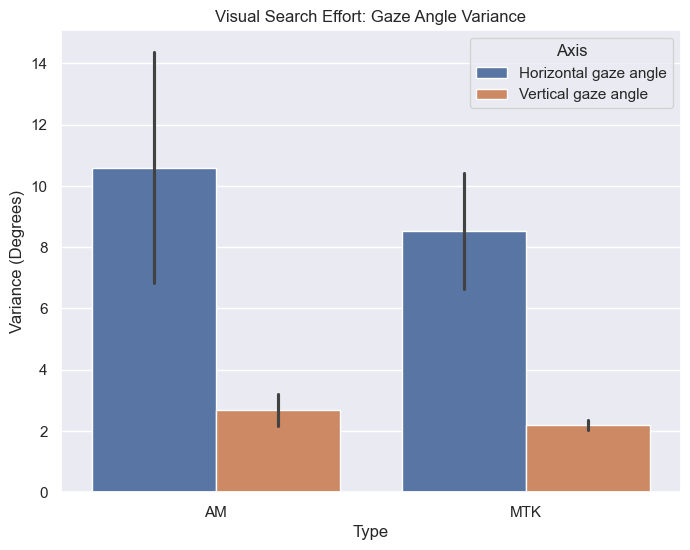

In [110]:
# Calculate the standard deviation (spread) of the gaze angles
gaze_variance = master_df.groupby(['Type', 'Speed'])[['Horizontal gaze angle', 'Vertical gaze angle']].std().reset_index()

print("--- Gaze Variance (Visual Searching Behavior) ---")
print(gaze_variance)

# Plotting the variance
melted_gaze = gaze_variance.melt(id_vars=['Type', 'Speed'], var_name='Axis', value_name='Gaze Variance (Std Dev)')

plt.figure(figsize=(8, 6))
sns.barplot(data=melted_gaze, x='Type', y='Gaze Variance (Std Dev)', hue='Axis')
plt.title('Visual Search Effort: Gaze Angle Variance')
plt.ylabel('Variance (Degrees)')
plt.show()